In [1]:
# This notebook demonstrates how to use ROSALIA to measure the expected zodiacal background in a simple image. 
import rosalia as rs
from astropy.time import Time
from astropy.coordinates import SkyCoord

> roman_wfi_exposure
Horizons Error: No ephemeris for target "Roman Space Telescope (spacecraft)" after A.D. 2026-OCT-06 13:01:09.1823 TD
Using Lagrange point L2 as a fallback for the observer position.
Computing Zodiacal light...


100%|██████████| 18/18 [00:00<00:00, 986.19it/s]


Generating scaled mosaic...


18it [01:06,  3.70s/it]


DEMO WARNING: make_stray_plot is Assuming F129.
21.277952402677585
21.350521174020145


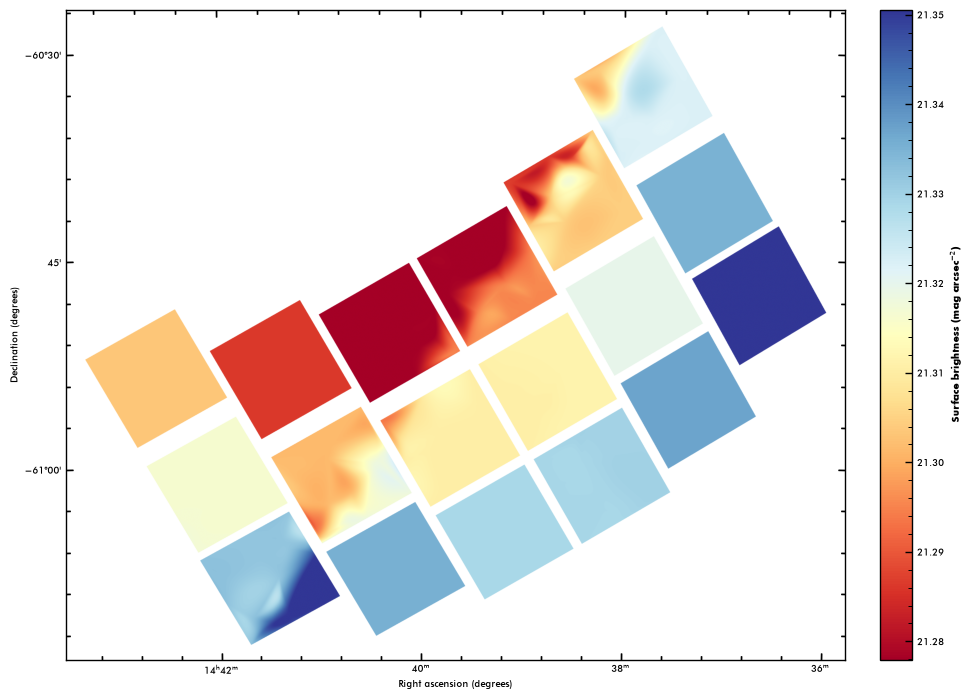

Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/tutorials/Pleiades_Roman_RA_219.920_DEC_-60.835_MJD_61406.00000_PA_030.00_zody.fits


In [2]:
# Define the target
target = 'alpha Centauri'
tgt = SkyCoord.from_name(target)
ra =  219.92041  # Right ascension, in degrees. 
dec = -60.835148 # Declination, in degrees.
PA = 30 # Position angle, in degrees.
date = Time("2027-01-01T00:00:00") # Date of the observation, in Astropy Time YYYY-MM-DDTHH:MM:SS format.
bandpass = "F129"
exptime = 600 # Exposure time, in seconds.

observer={"TELESCOP": "Roman/WFI", 
          "pointing": [ra, dec], 
          "FILTER":bandpass, 
          "PA_Y": PA, 
          "EXPSTART": date.mjd, 
          "EXPTIME": exptime}

prefix = "Pleiades"
custom_roman_exposure = rs.core.exposure(observer=observer, prefix=prefix) 

zodi_out = custom_roman_exposure.zodiacal(zody_mode="stsci")

In [ ]:
irsa_zodi_out = custom_roman_exposure.zodiacal(zody_mode="irsa")

Computing Zodiacal light...


  0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
zodipy_zodi_out = custom_roman_exposure.zodiacal(zody_mode="zodipy")

In [3]:
custom_roman_exposure.XYZ_HELIO_POS

<Quantity [-1.71570408e-01,  9.78315316e-01, -6.03306661e-05] AU>

In [4]:
from astropy.time import Time

date = Time("2026-09-09T00:00:00") # Date of the observation, in Astropy Time YYYY-MM-DDTHH:MM:SS format.

state_vectors = rs.horizons.interpolate_Roman_state_vectors(date.mjd)
XYZ_HELIO_POS = [state_vectors['X'], state_vectors['Y'], state_vectors['Z']]
print(XYZ_HELIO_POS)


[array(-8992645.29920602), array(-5512734.48127271), array(-2818156.78341806)]


In [5]:
import rosalia as rs
mjd=60000
rs.horizons.get_heliocentric_position_body(mjd, body="mars").to("km")

<Quantity [-9.85597886e+07,  2.00626414e+08,  9.46819377e+07] km>

In [6]:
def get_jpl_observer_name(observer_name):
    if observer_name.lower() == "l2": return("32")
    if observer_name.lower() == "hst" or observer_name.lower() == "hubble": return("-48")
    if observer_name.lower() == "jwst": return("-170")
    if observer_name.lower() == "rst" or observer_name.lower() == "roman": return("-211")
    if observer_name.lower() == "euclid": return("-680")



In [7]:
import rosalia as rs
from astropy.time import Time
mjd = Time("2026-12-09T00:00:00").mjd
body = "Roman"
state_vectors = rs.horizons.get_heliocoords(mjd, body)


Horizons Error: No ephemeris for target "Roman Space Telescope (spacecraft)" after A.D. 2026-OCT-06 13:01:09.1823 TD
Using Lagrange point L2 as a fallback for the observer position.
